In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)

In [10]:
# Generate data
X = np.linspace(0, 2*np.pi, 40)
print(X)

[0.         0.16110732 0.32221463 0.48332195 0.64442926 0.80553658
 0.96664389 1.12775121 1.28885852 1.44996584 1.61107316 1.77218047
 1.93328779 2.0943951  2.25550242 2.41660973 2.57771705 2.73882436
 2.89993168 3.061039   3.22214631 3.38325363 3.54436094 3.70546826
 3.86657557 4.02768289 4.1887902  4.34989752 4.51100484 4.67211215
 4.83321947 4.99432678 5.1554341  5.31654141 5.47764873 5.63875604
 5.79986336 5.96097068 6.12207799 6.28318531]


In [12]:
# True function
y_true = np.sin(X)


In [ ]:
# Add noise
noise = np.random.normal(0, 0.2, size=len(X))
y = y_true + noise
print(y_true + noise)

[ 0.15820639 -0.18187749  0.28055886 -0.28037021  0.11737142  0.43809113
 -0.19810727 -0.11325955  0.01993027 -0.10069513 -0.31013269  0.01371259
 -0.21246074  0.09471849 -0.18388485  0.30998688 -0.15665066 -0.0644123
  0.16270344 -0.24617286  0.04549199  0.26142855 -0.32149665  0.03692677
  0.05197656  0.15636457 -0.24739014 -0.26409132  0.10438831  0.05939693
  0.05009857  0.06928964 -0.13600494  0.04645074  0.05861449 -0.14287028
  0.3731549   0.09476658 -0.2382607   0.13131072]


In [13]:
# Reshape for sklearn
X = X.reshape(-1, 1)
print(X.shape)

(40, 1)


In [6]:
# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 28
Validation samples: 12


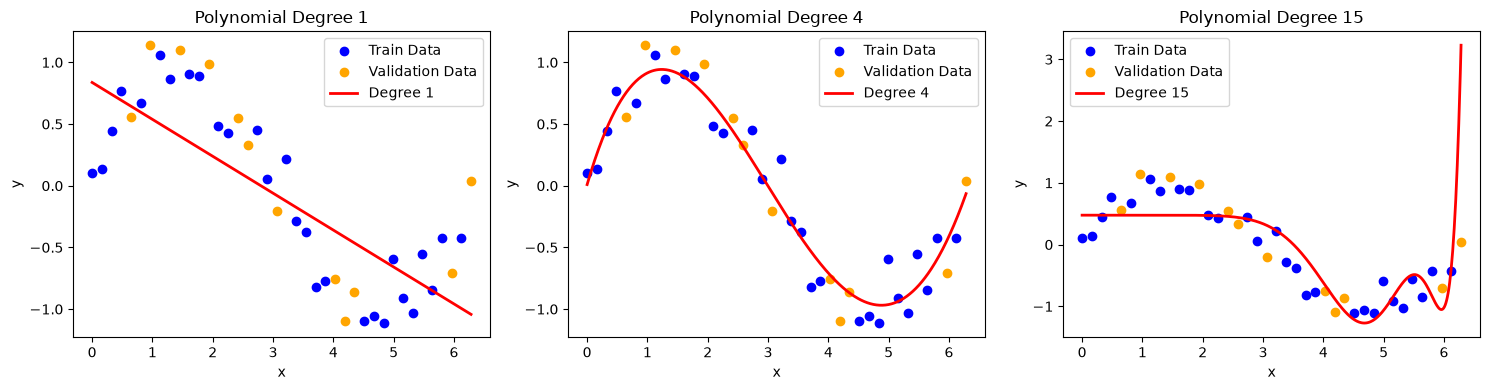

In [7]:
degrees = [1, 4, 15]

x_plot = np.linspace(0, 2*np.pi, 500).reshape(-1, 1)

plt.figure(figsize=(15,4))

for i, degree in enumerate(degrees):

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("linear", LinearRegression())
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(x_plot)

    plt.subplot(1,3,i+1)

    plt.scatter(X_train, y_train,
                color='blue',
                label='Train Data')

    plt.scatter(X_val, y_val,
                color='orange',
                label='Validation Data')

    plt.plot(x_plot, y_pred,
             color='red',
             linewidth=2,
             label=f'Degree {degree}')

    plt.title(f'Polynomial Degree {degree}')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()

plt.tight_layout()
plt.show()

In [8]:
degrees = range(1, 21)

train_errors = []
val_errors = []

for degree in degrees:

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("linear", LinearRegression())
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_mse = mean_squared_error(y_train, train_pred)
    val_mse = mean_squared_error(y_val, val_pred)

    train_errors.append(train_mse)
    val_errors.append(val_mse)

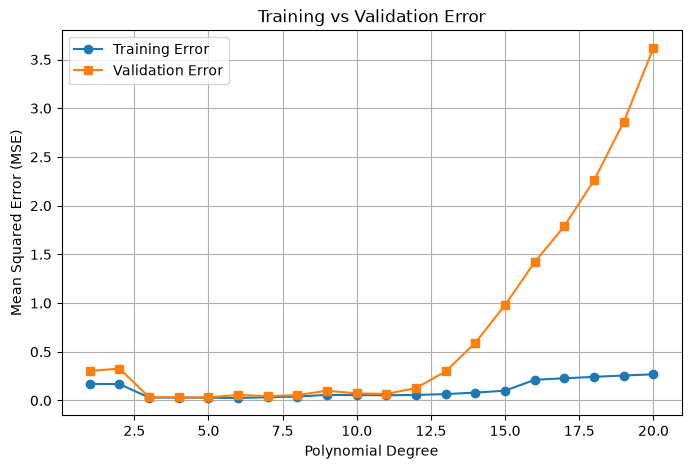

In [9]:
plt.figure(figsize=(8,5))

plt.plot(degrees,
         train_errors,
         marker='o',
         label='Training Error')

plt.plot(degrees,
         val_errors,
         marker='s',
         label='Validation Error')

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Training vs Validation Error")
plt.legend()
plt.grid(True)

plt.show()